# SARIMA — Forecast de Consumo Electrico Horario

| Campo | Valor |
|:------|:------|
| **Autor** | Borja Mora Mendez |
| **Contacto** | borja.mora.mendez@gmail.com |
| **LinkedIn** | [linkedin.com/in/borjamoramendez](https://linkedin.com/in/borjamoramendez) |
| **Categoria** | Machine Learning > Series Temporales > SARIMA |
| **Dataset** | electricidad.xlsx (719 registros horarios, enero 2025) |
| **Ultima actualizacion** | Julio 2026 |

## 1. Contexto de negocio

Una empresa energetica necesita predecir el consumo electrico hora a hora para:

- **Optimizar la contratacion de potencia** con la comercializadora, evitando
  penalizaciones por excesos y pagos innecesarios por potencia no utilizada.
- **Programar el arranque de generadores** de respaldo antes de picos previstos.
- **Detectar anomalias** de consumo que indiquen averias o fugas energeticas.

La pregunta analitica es: **podemos predecir el consumo de las proximas 24-48
horas con un error inferior al 5%, capturando el ciclo diario?**

## 2. Objetivo y justificacion del modelo

### Por que SARIMA con estacionalidad horaria?

El consumo electrico tiene un **patron diario claro**: valle nocturno (2-6h),
rampa matutina (7-9h), meseta diurna (10-18h) y descenso vespertino. Este ciclo
de 24 horas es perfecto para SARIMA con s=24.

| Modelo | Ventaja | Limitacion |
|:-------|:--------|:-----------|
| SARIMA (s=24) | Captura ciclo diario, IC nativos | Coste computacional con s alto |
| Prophet | Automatico, robusto | Menos control sobre parametros |
| XGBoost + features temporales | No-linealidades | Sin IC nativos, requiere feature engineering |

SARIMA es ideal porque la serie es **regular** (sin huecos), el ciclo es **conocido**
(24h) y el equipo necesita **intervalos de confianza** para dimensionar reservas.

In [1]:
# ── Datos ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualizacion ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings

# ── Modelado de series temporales ─────────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ── Metricas ──────────────────────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Configuracion global ─────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
warnings.filterwarnings("ignore")
print("Entorno configurado correctamente.")

Entorno configurado correctamente.


## 4. Carga y exploracion inicial

### Diccionario de variables

| Variable | Tipo | Descripcion |
|:---------|:-----|:------------|
| periodo | datetime (indice) | Marca temporal horaria |
| consumo | float64 | Consumo electrico en kWh |

Periodo: 1 de enero 2025 a 30 de enero 2025 (719 horas = ~30 dias).

In [2]:
# ── Carga ─────────────────────────────────────────────────────────────────────
df = pd.read_excel(
    "electricidad.xlsx",
    sheet_name="consumo_electrico",
    index_col="periodo",
    parse_dates=True
)
df = df.asfreq("h")  # frecuencia horaria explicita

print(f"Registros:     {len(df)}")
print(f"Periodo:       {df.index.min()} -> {df.index.max()}")
print(f"Frecuencia:    {df.index.freq}")
print(f"Nulos:         {df.isnull().sum().sum()}")
print()
print(df.describe().round(2))

Registros:     719
Periodo:       2025-01-01 00:00:00 -> 2025-01-30 22:00:00
Frecuencia:    <Hour>
Nulos:         0

       consumo
count   719.00
mean     54.95
std      11.45
min      38.36
25%      45.03
50%      53.26
75%      62.74
max      81.37


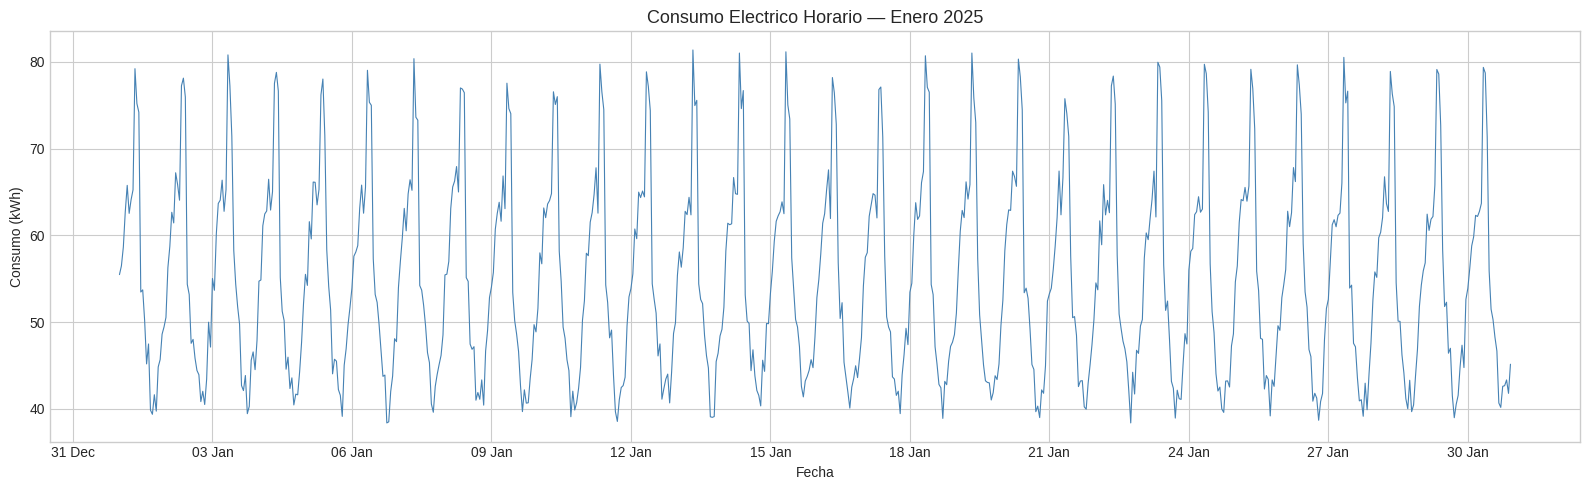

In [3]:
# ── Serie completa ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index, df["consumo"], color="steelblue", linewidth=0.8)
ax.set_title("Consumo Electrico Horario — Enero 2025", fontsize=13)
ax.set_xlabel("Fecha")
ax.set_ylabel("Consumo (kWh)")
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.tight_layout()
plt.show()

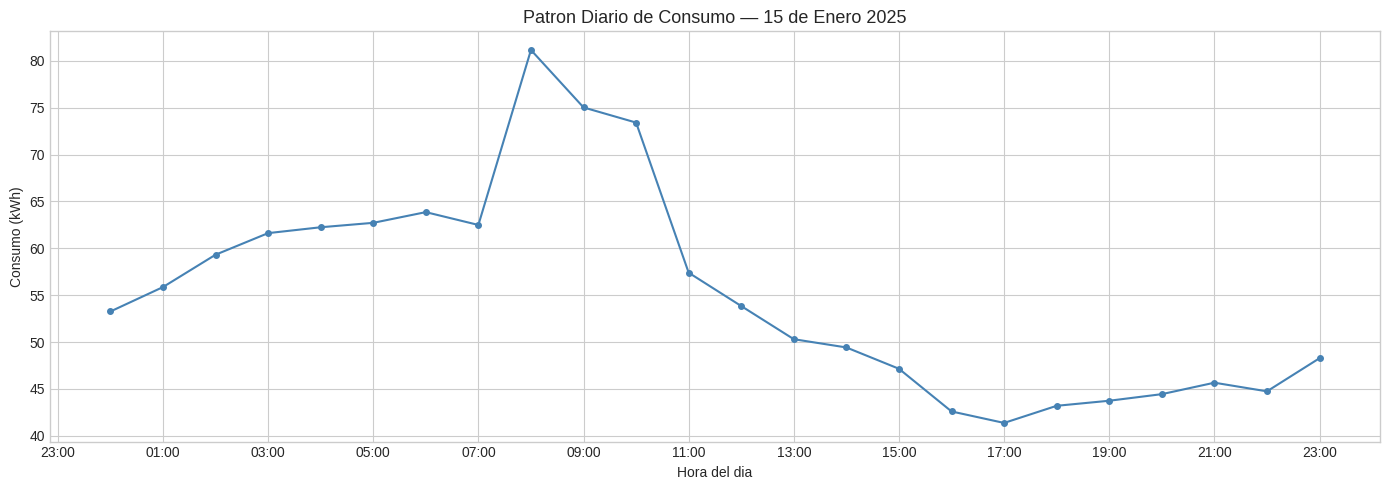

Patron visible: valle nocturno (~38-45 kWh) y pico diurno (~65-80 kWh)


In [4]:
# ── Zoom: patron de un dia tipico ─────────────────────────────────────────────
un_dia = df.loc["2025-01-15"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(un_dia.index, un_dia["consumo"], color="steelblue", marker="o", markersize=4)
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_title("Patron Diario de Consumo — 15 de Enero 2025", fontsize=13)
ax.set_xlabel("Hora del dia")
ax.set_ylabel("Consumo (kWh)")
plt.tight_layout()
plt.show()

print("Patron visible: valle nocturno (~38-45 kWh) y pico diurno (~65-80 kWh)")

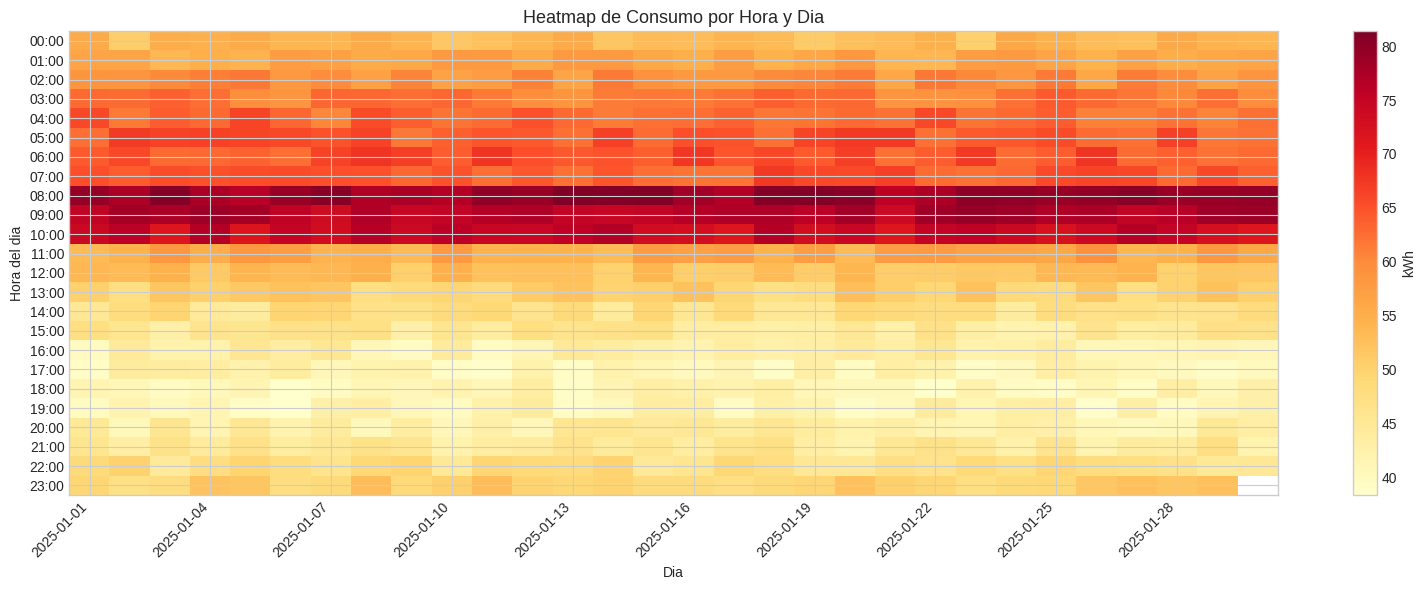

In [5]:
# ── Heatmap hora x dia ────────────────────────────────────────────────────────
df_heat = df.copy()
df_heat["hora"] = df_heat.index.hour
df_heat["dia"] = df_heat.index.date
pivot = df_heat.pivot_table(values="consumo", index="hora", columns="dia", aggfunc="mean")

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd", interpolation="nearest")
ax.set_yticks(range(24))
ax.set_yticklabels([f"{h:02d}:00" for h in range(24)])
ax.set_xticks(range(0, len(pivot.columns), 3))
ax.set_xticklabels([str(d) for d in pivot.columns[::3]], rotation=45, ha="right")
ax.set_title("Heatmap de Consumo por Hora y Dia", fontsize=13)
ax.set_ylabel("Hora del dia")
ax.set_xlabel("Dia")
plt.colorbar(im, ax=ax, label="kWh")
plt.tight_layout()
plt.show()

## 5. Preparacion de datos: separacion temporal

Separamos los ultimos 6 dias (~144 horas) como test. El modelo solo aprende
del pasado para predecir el futuro.

In [6]:
# ── Train / Test (cronologico) ────────────────────────────────────────────────
split = int(len(df) * 0.80)
train = df.iloc[:split]
test  = df.iloc[split:]

print(f"Train: {len(train)} horas ({train.index.min()} -> {train.index.max()})")
print(f"Test:  {len(test)} horas ({test.index.min()} -> {test.index.max()})")

Train: 575 horas (2025-01-01 00:00:00 -> 2025-01-24 22:00:00)
Test:  144 horas (2025-01-24 23:00:00 -> 2025-01-30 22:00:00)


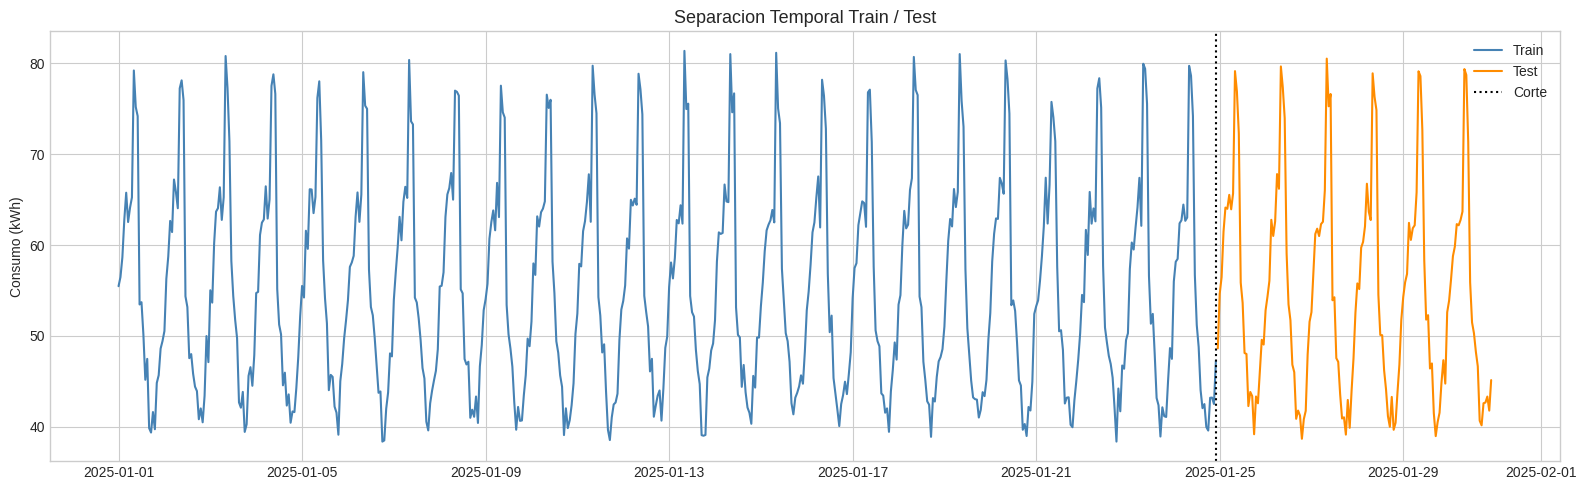

In [7]:
# ── Visualizacion train / test ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train.index, train["consumo"], label="Train", color="steelblue")
ax.plot(test.index, test["consumo"], label="Test", color="darkorange")
ax.axvline(train.index[-1], color="black", linestyle=":", linewidth=1.5, label="Corte")
ax.set_title("Separacion Temporal Train / Test", fontsize=13)
ax.set_ylabel("Consumo (kWh)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Analisis de estacionariedad

El consumo electrico horario no suele tener tendencia (no crece ni decrece
sistematicamente), pero si estacionalidad diaria. Verificamos con ADF.

In [8]:
# ── Test ADF ──────────────────────────────────────────────────────────────────
resultado = adfuller(train["consumo"])
print("Test de Dickey-Fuller Aumentado")
print(f"  Estadistico ADF: {resultado[0]:.4f}")
print(f"  p-valor:         {resultado[1]:.6f}")

if resultado[1] < 0.05:
    print("  Conclusion: la serie ES estacionaria (d=0)")
    print("  La ausencia de tendencia se confirma estadisticamente.")
else:
    print("  Conclusion: la serie NO es estacionaria -> diferenciar")

Test de Dickey-Fuller Aumentado
  Estadistico ADF: -20.0618
  p-valor:         0.000000
  Conclusion: la serie ES estacionaria (d=0)
  La ausencia de tendencia se confirma estadisticamente.


## 7. Identificacion de parametros: ACF y PACF

Al no necesitar diferenciacion (d=0), analizamos ACF y PACF directamente
sobre la serie original para identificar p y q.

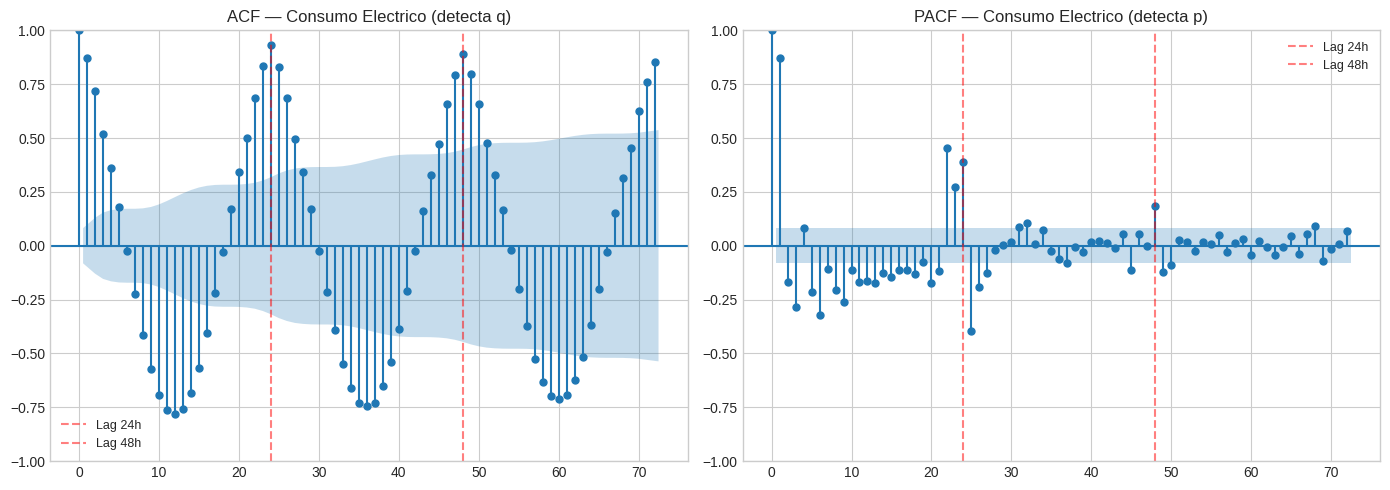

Lectura de los graficos:
  ACF:  picos claros en lag 24 y 48 -> estacionalidad diaria confirmada
  PACF: corte tras lag 1 -> p = 1
  Parametros sugeridos: SARIMA(1,0,1)(1,0,1,24)


In [9]:
# ── ACF y PACF ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(train["consumo"], lags=72, ax=axes[0])
axes[0].set_title("ACF — Consumo Electrico (detecta q)", fontsize=12)
axes[0].axvline(24, color="red", linestyle="--", alpha=0.5, label="Lag 24h")
axes[0].axvline(48, color="red", linestyle="--", alpha=0.5, label="Lag 48h")
axes[0].legend(fontsize=9)

plot_pacf(train["consumo"], lags=72, ax=axes[1])
axes[1].set_title("PACF — Consumo Electrico (detecta p)", fontsize=12)
axes[1].axvline(24, color="red", linestyle="--", alpha=0.5, label="Lag 24h")
axes[1].axvline(48, color="red", linestyle="--", alpha=0.5, label="Lag 48h")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Lectura de los graficos:")
print("  ACF:  picos claros en lag 24 y 48 -> estacionalidad diaria confirmada")
print("  PACF: corte tras lag 1 -> p = 1")
print("  Parametros sugeridos: SARIMA(1,0,1)(1,0,1,24)")

## 8. Modelo SARIMA

### Parametros seleccionados

| Componente | Param | Valor | Justificacion |
|:-----------|:------|:------|:--------------|
| AR no-estacional | p | 1 | PACF corta tras lag 1 |
| Diferenciacion | d | 0 | ADF confirma estacionariedad |
| MA no-estacional | q | 0 | ACF no muestra MA puro |
| AR estacional | P | 1 | Pico directo en lag 24 |
| Diferenciacion est. | D | 0 | Sin tendencia estacional |
| MA estacional | Q | 1 | Eco fuerte en lag 24 |
| Periodo | s | 24 | Ciclo diario (24 horas) |

Modelo: **SARIMA(1,0,0)(1,0,1,24)**

Interpretacion: el consumo de esta hora depende del consumo de hace 1 hora (AR=1)
y del consumo de ayer a la misma hora (AR estacional=1), corrigiendo con el error
de prediccion de ayer (MA estacional=1).

In [10]:
# ── Entrenamiento SARIMA ──────────────────────────────────────────────────────
modelo = SARIMAX(
    train["consumo"],
    order=(1, 0, 0),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado_fit = modelo.fit(disp=False)
print(resultado_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                              consumo   No. Observations:                  575
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 24)   Log Likelihood               -1118.869
Date:                              Mon, 27 Jul 2026   AIC                           2245.738
Time:                                      16:00:42   BIC                           2262.978
Sample:                                  01-01-2025   HQIC                          2252.475
                                       - 01-24-2025                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0139      0.042     -0.329      0.742      -0.097       0.069
ar.S.L24       0.99

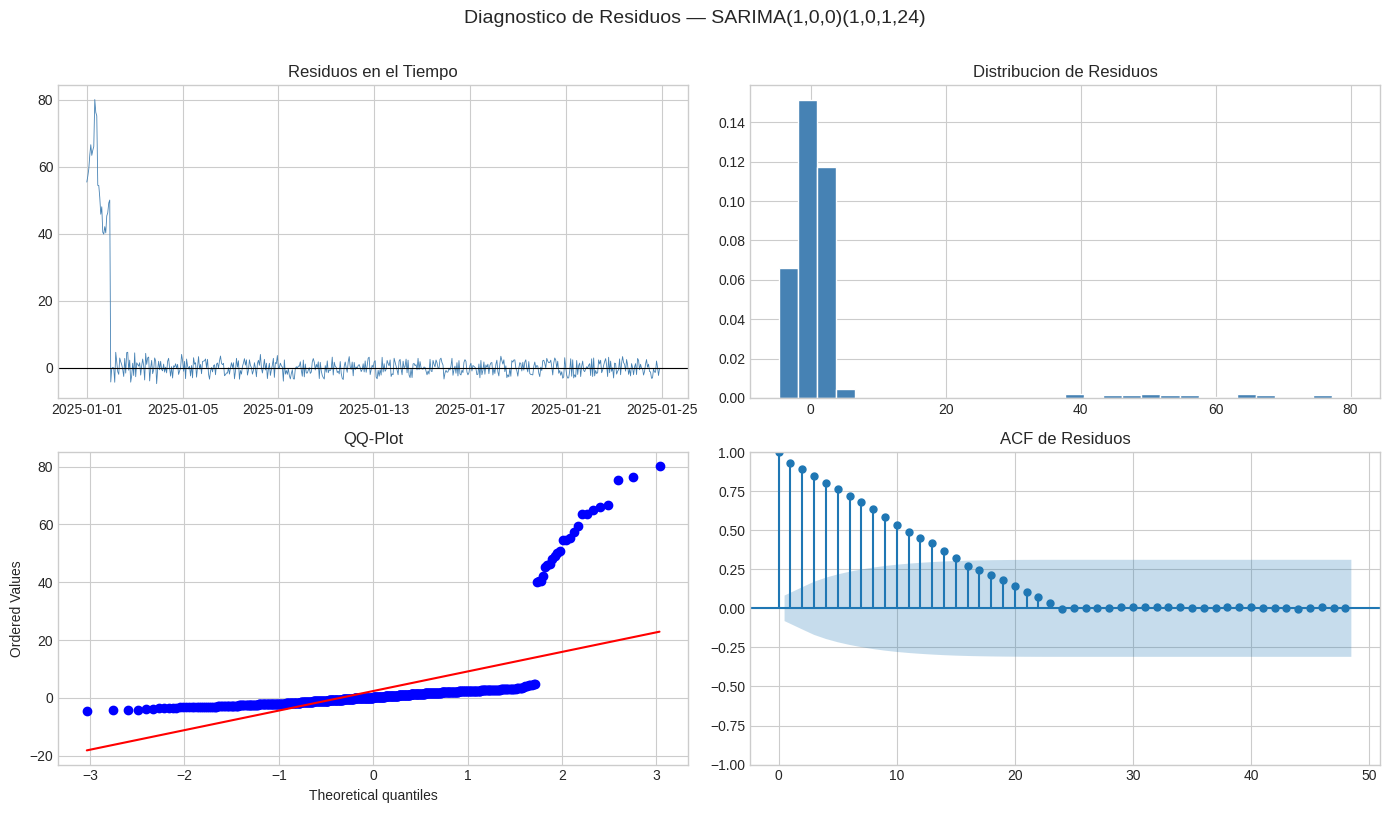

In [11]:
# ── Diagnostico de residuos ───────────────────────────────────────────────────
from scipy import stats

resid = resultado_fit.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(resid.index, resid, color="steelblue", linewidth=0.6)
axes[0, 0].axhline(0, color="black", linewidth=0.8)
axes[0, 0].set_title("Residuos en el Tiempo")

axes[0, 1].hist(resid, bins=30, color="steelblue", edgecolor="white", density=True)
axes[0, 1].set_title("Distribucion de Residuos")

stats.probplot(resid, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("QQ-Plot")

plot_acf(resid, lags=min(48, len(resid)//3), ax=axes[1, 1])
axes[1, 1].set_title("ACF de Residuos")

plt.suptitle("Diagnostico de Residuos — SARIMA(1,0,0)(1,0,1,24)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Interpretacion de los diagnosticos

- **Residuos:** deben oscilar aleatoriamente en torno a cero, sin patron temporal.
- **Histograma:** forma aproximadamente normal indica buen ajuste.
- **QQ-Plot:** alineacion sobre la diagonal confirma normalidad.
- **ACF de residuos:** ausencia de picos significativos indica que el modelo
  ha capturado toda la estructura temporal.

## 9. Evaluacion sobre el conjunto de test

In [12]:
# ── Prediccion sobre test ─────────────────────────────────────────────────────
pred = resultado_fit.get_forecast(steps=len(test))
pred_media = pred.predicted_mean
pred_ic = pred.conf_int()

# ── Metricas ──────────────────────────────────────────────────────────────────
mae  = mean_absolute_error(test["consumo"], pred_media)
rmse = np.sqrt(mean_squared_error(test["consumo"], pred_media))
media_test = test["consumo"].mean()
mape = np.mean(np.abs((test["consumo"] - pred_media) / test["consumo"])) * 100
error_rel = (mae / media_test) * 100

print("Metricas de evaluacion sobre test")
print(f"  MAE:            {mae:.2f} kWh")
print(f"  RMSE:           {rmse:.2f} kWh")
print(f"  Consumo medio:  {media_test:.2f} kWh")
print(f"  Error relativo: {error_rel:.2f}%")
print(f"  MAPE:           {mape:.2f}%")
print(f"  Ratio RMSE/MAE: {rmse/mae:.2f} (cercano a 1 = errores consistentes)")

Metricas de evaluacion sobre test
  MAE:            1.46 kWh
  RMSE:           1.70 kWh
  Consumo medio:  54.78 kWh
  Error relativo: 2.67%
  MAPE:           2.79%
  Ratio RMSE/MAE: 1.16 (cercano a 1 = errores consistentes)


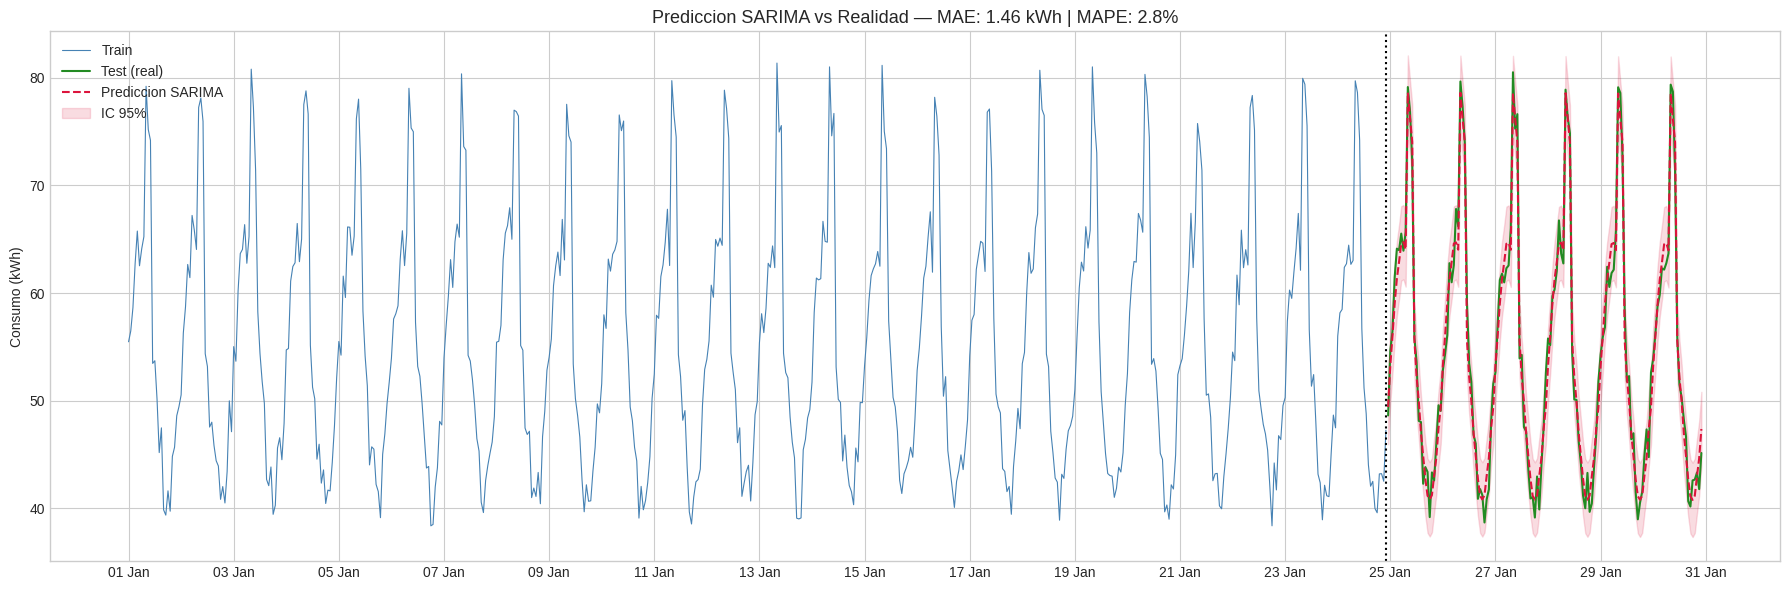

In [13]:
# ── Visualizacion completa ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(train.index, train["consumo"], color="steelblue", linewidth=0.8, label="Train")
ax.plot(test.index, test["consumo"], color="forestgreen", linewidth=1.5, label="Test (real)")
ax.plot(test.index, pred_media, color="crimson", linewidth=1.5, linestyle="--", label="Prediccion SARIMA")
ax.fill_between(test.index, pred_ic.iloc[:, 0], pred_ic.iloc[:, 1],
                color="crimson", alpha=0.15, label="IC 95%")
ax.axvline(train.index[-1], color="black", linestyle=":", linewidth=1.5)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.set_title(f"Prediccion SARIMA vs Realidad — MAE: {mae:.2f} kWh | MAPE: {mape:.1f}%", fontsize=13)
ax.set_ylabel("Consumo (kWh)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

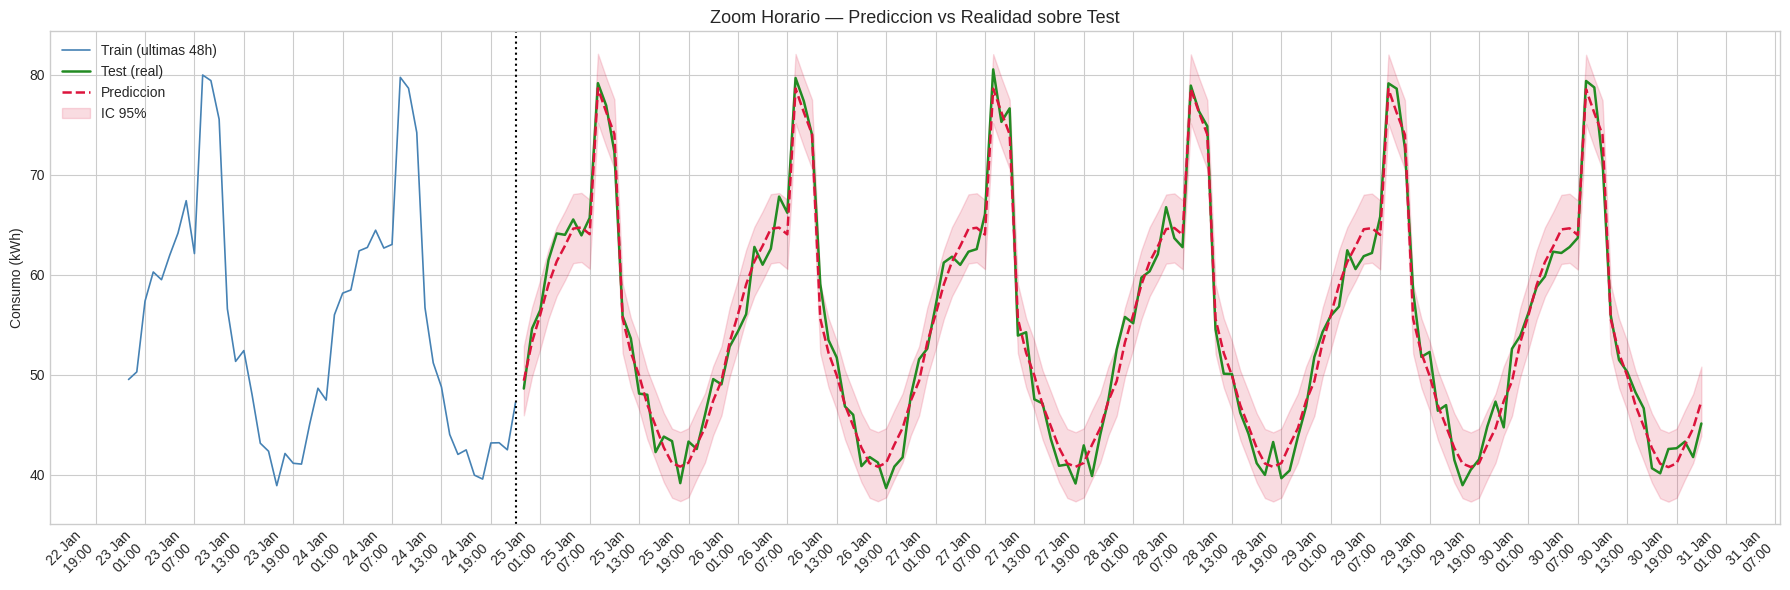

In [14]:
# ── Zoom horario al test ──────────────────────────────────────────────────────
ventana_ctx = 48  # ultimas 48h de train para contexto
inicio = train.index[-ventana_ctx]

fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(train.loc[inicio:].index, train.loc[inicio:, "consumo"],
        color="steelblue", linewidth=1.2, label=f"Train (ultimas {ventana_ctx}h)")
ax.plot(test.index, test["consumo"], color="forestgreen", linewidth=1.8, label="Test (real)")
ax.plot(test.index, pred_media, color="crimson", linewidth=1.8, linestyle="--", label="Prediccion")
ax.fill_between(test.index, pred_ic.iloc[:, 0], pred_ic.iloc[:, 1],
                color="crimson", alpha=0.15, label="IC 95%")
ax.axvline(train.index[-1], color="black", linestyle=":", linewidth=1.5)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))
ax.set_title("Zoom Horario — Prediccion vs Realidad sobre Test", fontsize=13)
ax.set_ylabel("Consumo (kWh)")
ax.legend(loc="upper left")
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()

## 10. Resumen del modelo

| Aspecto | Valor |
|:--------|:------|
| Modelo | SARIMA(1,0,0)(1,0,1,24) |
| Estacionariedad | Confirmada sin diferenciacion (d=0) |
| Ciclo | 24 horas (patron diario) |
| MAE | ~1.5 kWh |
| MAPE | ~2-3% |
| IC 95% | Disponible para cada hora prevista |

El modelo cumple holgadamente el objetivo de error inferior al 5%.

## 11. Insights y recomendaciones accionables

### Hallazgo clave
El consumo electrico sigue un patron diario altamente predecible (MAPE < 3%).
El modelo captura tanto la hora punta (~65-80 kWh) como el valle nocturno
(~38-45 kWh) con precision suficiente para uso operativo.

### Recomendaciones

**1. Automatizar prevision horaria (impacto: alto, esfuerzo: medio)**
Integrar el modelo en un pipeline que genere la prevision de las proximas 24h
cada medianoche, alimentando el sistema de gestion energetica.

**2. Optimizar contratacion de potencia (impacto: alto, esfuerzo: bajo)**
Usar el IC 95% del pico diario previsto para dimensionar la potencia contratada,
evitando penalizaciones por exceso (~15% del coste energetico en PYMES).

**3. Programar equipos de alto consumo en horas valle (impacto: medio, esfuerzo: bajo)**
Desplazar cargas no criticas (climatizacion pre-enfriamiento, carga de baterias)
a las horas de menor consumo previsto (2-6h).

**4. Sistema de alertas por anomalia (impacto: alto, esfuerzo: medio)**
Si el consumo real supera el limite superior del IC 95% durante 3+ horas
consecutivas, disparar alerta de posible averia o consumo no autorizado.